## Unit 6: Exercises

## Finetuning a Pretrained LLM on a Medical Question Answering Task

Name: Shane D. Canabo <br>
CYS: BSCS 3A AI <br>
Date: 04/24/2026

This notebook demonstrates a lightweight medical-domain fine-tuning workflow using a pretrained Hugging Face LLM and a dataset from the **Medical LLMs Finetuning Datasets** collection.

The activity follows these steps:
1. Identify the task to be performed.
2. Identify the domain used for fine-tuning.
3. Identify the LLM to be used.
4. Establish the fine-tuning configuration.
5. Perform evaluation for the chosen task.

In [2]:
# Core libraries
import os
import random
import numpy as np
import torch

from datasets import load_dataset
import evaluate
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Step 4: Establish the fine-tuning configuration

The setup below keeps the run lightweight:
- a small pretrained seq2seq model
- a capped training subset
- short source and target lengths
- ROUGE and exact match for evaluation

If a GPU is available, the notebook automatically uses a larger batch size and mixed precision.

## Step 3: Identify the LLM

The pretrained LLM used for fine-tuning is **google/flan-t5-small**. It is a compact text-to-text model, which makes it practical for a notebook demo while still supporting instruction-style question answering.

## Step 2: Identify the domain

The fine-tuning domain is **medicine and healthcare**. The dataset used here, **MedQuad-MedicalQnADataset**, is part of the Hugging Face collection **Medical LLMs Finetuning Datasets** and contains medical question-answer pairs.

## Step 1: Identify the task

The task chosen for this notebook is **medical question answering**. The model learns to generate a natural-language answer when given a medical question, and the quality of the generated answer is measured against the reference answer.

## Fine-tuning Configuration

The setup below keeps the run lightweight:
- a small pretrained seq2seq model
- a capped training subset
- short source and target lengths
- ROUGE and exact match for evaluation

If a GPU is available, the notebook automatically uses a larger batch size and mixed precision.

In [3]:
# Load the medical QA dataset from Hugging Face and inspect its structure.
dataset_name = "mlabonne/MedQuad-MedicalQnADataset"
raw_dataset = load_dataset(dataset_name)
train_split = raw_dataset["train"]

print(raw_dataset)
print("Columns:", train_split.column_names)
print("Sample row:", train_split[0])

def infer_qa_columns(example):
    keys = list(example.keys())
    lower_lookup = {key.lower(): key for key in keys}

    question_candidates = ["question", "query", "prompt", "instruction", "input", "context"]
    answer_candidates = ["answer", "response", "completion", "output", "target", "label"]

    question_column = next((lower_lookup[name] for name in question_candidates if name in lower_lookup), keys[0])
    answer_column = next(
        (lower_lookup[name] for name in answer_candidates if name in lower_lookup and lower_lookup[name] != question_column),
        keys[1] if len(keys) > 1 else keys[0],
    )
    return question_column, answer_column

question_column, answer_column = infer_qa_columns(train_split[0])
print(f"Question column: {question_column}")
print(f"Answer column: {answer_column}")

def build_prompt(example):
    question_text = str(example[question_column]).strip()
    context_text = str(example.get("context", "")).strip()

    prompt_parts = []
    if context_text:
        prompt_parts.append(f"Context: {context_text}")
    prompt_parts.append(f"Question: {question_text}")
    return "\n".join(prompt_parts)

def to_text_pair(example):
    return {
        "input_text": f"medical question: {build_prompt(example)}",
        "target_text": str(example[answer_column]).strip(),
    }

sample_size = min(2000, len(train_split))
subset = train_split.shuffle(seed=SEED).select(range(sample_size))
split_dataset = subset.train_test_split(test_size=0.1, seed=SEED)
prepared_splits = split_dataset.map(
    to_text_pair,
    remove_columns=subset.column_names,
    desc="Preparing medical QA prompts",
)

print(prepared_splits)

DatasetDict({
    train: Dataset({
        features: ['qtype', 'instruction', 'output'],
        num_rows: 16359
    })
})
Columns: ['qtype', 'instruction', 'output']
Sample row: {'qtype': 'susceptibility', 'instruction': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?', 'output': 'LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.'}
Question column: instruction
Answer column: output
DatasetDict({
    train: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 1800
    })
    test: Dataset({
        features: ['input_text', 'target_text'],
   

In [3]:
# Convert the medical QA dataset into input/output pairs that a text-to-text model can learn.
dataset_name = "mlabonne/MedQuad-MedicalQnADataset"
raw_dataset = load_dataset(dataset_name)
train_split = raw_dataset["train"]

print(raw_dataset)
print("Columns:", train_split.column_names)
print("Sample row:", train_split[0])

def infer_qa_columns(example):
    keys = list(example.keys())
    lower_lookup = {key.lower(): key for key in keys}

    question_candidates = ["question", "query", "prompt", "instruction", "input", "context"]
    answer_candidates = ["answer", "response", "completion", "output", "target", "label"]

    question_column = next((lower_lookup[name] for name in question_candidates if name in lower_lookup), keys[0])
    answer_column = next(
        (lower_lookup[name] for name in answer_candidates if name in lower_lookup and lower_lookup[name] != question_column),
        keys[1] if len(keys) > 1 else keys[0],
    )
    return question_column, answer_column

question_column, answer_column = infer_qa_columns(train_split[0])
print(f"Question column: {question_column}")
print(f"Answer column: {answer_column}")

def build_prompt(example):
    question_text = str(example[question_column]).strip()
    context_text = str(example.get("context", "")).strip()

    prompt_parts = []
    if context_text:
        prompt_parts.append(f"Context: {context_text}")
    prompt_parts.append(f"Question: {question_text}")
    return "\n".join(prompt_parts)

def to_text_pair(example):
    return {
        "input_text": f"medical question: {build_prompt(example)}",
        "target_text": str(example[answer_column]).strip(),
    }

sample_size = min(2000, len(train_split))
subset = train_split.shuffle(seed=SEED).select(range(sample_size))
split_dataset = subset.train_test_split(test_size=0.1, seed=SEED)
prepared_splits = split_dataset.map(
    to_text_pair,
    remove_columns=subset.column_names,
    desc="Preparing medical QA prompts",
)

print(prepared_splits)

DatasetDict({
    train: Dataset({
        features: ['qtype', 'instruction', 'output'],
        num_rows: 16359
    })
})
Columns: ['qtype', 'instruction', 'output']
Sample row: {'qtype': 'susceptibility', 'instruction': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?', 'output': 'LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.'}
Question column: instruction
Answer column: output
DatasetDict({
    train: Dataset({
        features: ['input_text', 'target_text'],
        num_rows: 1800
    })
    test: Dataset({
        features: ['input_text', 'target_text'],
   

In [4]:
# Tokenize the prepared QA pairs so they are ready for seq2seq training.
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_source_length = 256
max_target_length = 128

def tokenize_batch(batch):
    model_inputs = tokenizer(
        batch["input_text"],
        max_length=max_source_length,
        truncation=True,
    )
    target_tokens = tokenizer(
        text_target=batch["target_text"],
        max_length=max_target_length,
        truncation=True,
    )
    model_inputs["labels"] = target_tokens["input_ids"]
    return model_inputs

tokenized_splits = prepared_splits.map(
    tokenize_batch,
    batched=True,
    remove_columns=prepared_splits["train"].column_names,
    desc="Tokenizing medical QA data",
)

In [8]:
# Build the model, data collator, metric, and training arguments.
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
rouge_metric = evaluate.load("rouge")

max_source_length = 256
max_target_length = 128

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)
    labels = np.asarray(labels)

    if predictions.ndim == 3:
        predictions = np.argmax(predictions, axis=-1)

    predictions = np.where(predictions >= 0, predictions, tokenizer.pad_token_id)
    labels = np.where(labels >= 0, labels, tokenizer.pad_token_id)

    decoded_predictions = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_predictions = [text.strip().lower() for text in decoded_predictions]
    decoded_labels = [text.strip().lower() for text in decoded_labels]

    rouge_scores = rouge_metric.compute(predictions=decoded_predictions, references=decoded_labels)
    exact_match = np.mean([pred == ref for pred, ref in zip(decoded_predictions, decoded_labels)])

    return {
        "rouge1": round(rouge_scores["rouge1"], 4),
        "rouge2": round(rouge_scores["rouge2"], 4),
        "rougeL": round(rouge_scores["rougeL"], 4),
        "exact_match": round(float(exact_match), 4),
    }

training_args = Seq2SeqTrainingArguments(
    output_dir="medical_qa_flan_t5_small",
    learning_rate=2e-4,
    num_train_epochs=1,
    per_device_train_batch_size=4 if torch.cuda.is_available() else 1,
    per_device_eval_batch_size=4 if torch.cuda.is_available() else 1,
    gradient_accumulation_steps=2 if torch.cuda.is_available() else 1,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="no",
    predict_with_generate=True,
    generation_max_length=max_target_length,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_splits["train"],
    eval_dataset=tokenized_splits["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [9]:
# Run the fine-tuning loop.
train_result = trainer.train()
print(train_result)

# Save the trained model and tokenizer so the notebook output can be reused later.
trainer.save_model(training_args.output_dir)
tokenizer.save_pretrained(training_args.output_dir)

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Exact Match
1,2.118259,2.049770,0.327700,0.205900,0.294200,0.015000


TrainOutput(global_step=1800, training_loss=2.440322002834744, metrics={'train_runtime': 1458.6627, 'train_samples_per_second': 1.234, 'train_steps_per_second': 1.234, 'total_flos': 13891321485312.0, 'train_loss': 2.440322002834744, 'epoch': 1.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('medical_qa_flan_t5_small\\tokenizer_config.json',
 'medical_qa_flan_t5_small\\tokenizer.json')

In [11]:
# Evaluate the fine-tuned model on the held-out split and inspect a few generated answers.
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)
trainer.model.to(device)
eval_metrics = trainer.evaluate()
print("Evaluation metrics:")
for metric_name, metric_value in eval_metrics.items():
    print(f"{metric_name}: {metric_value}")

# Show a few qualitative examples.
sample_examples = prepared_splits["test"].select(range(min(3, len(prepared_splits["test"]))))
for index, example in enumerate(sample_examples, start=1):
    prompt = example["input_text"]
    reference = example["target_text"]
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length).to(device)
    generated_tokens = trainer.model.generate(**inputs, max_new_tokens=max_target_length)
    prediction = tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

    print(f"\nExample {index}")
    print(f"Prompt: {prompt}")
    print(f"Reference: {reference}")
    print(f"Prediction: {prediction}")

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluation metrics:
eval_loss: 2.0497701168060303
eval_rouge1: 0.3277
eval_rouge2: 0.2059
eval_rougeL: 0.2942
eval_exact_match: 0.015
eval_runtime: 286.4504
eval_samples_per_second: 0.698
eval_steps_per_second: 0.698
epoch: 1.0


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Example 1
Prompt: medical question: Question: What are the treatments for Heart Attack ?
Reference: There are many medicines that are used to treat a heart attack. - Clot-busters or thrombolytic drugs dissolve blood clots that are blocking blood flow to the heart.  - Beta blockers decrease the workload on your heart by slowing your heart rate.  - Angiotensin-converting enzyme (ACE) inhibitors lower your blood pressure and reduce the strain on your heart.  - Nitrates, such as nitroglycerin  relax blood vessels and relieve chest pain.  - Anticoagulants thin the blood and prevent clots from forming in your arteries.  - Antiplatelet medications, such as aspirin and clopidogrel, stop platelets from clumping together to form clots. These medications are given to people who have had a heart attack, have angina, or have had angioplasty. Clot-busters or thrombolytic drugs dissolve blood clots that are blocking blood flow to the heart. Beta blockers decrease the workload on your heart by slowin

Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Example 2
Prompt: medical question: Question: Is 9q22.3 microdeletion inherited ?
Reference: 9q22.3 microdeletions are inherited in an autosomal dominant pattern, which means that missing genetic material from one of the two copies of chromosome 9 in each cell is sufficient to cause delayed development, intellectual disability, and the features of Gorlin syndrome.  A 9q22.3 microdeletion most often occurs in people whose parents do not carry the chromosomal change. In these cases, the deletion occurs as a random (de novo) event during the formation of reproductive cells (eggs or sperm) in a parent or in early embryonic development. De novo chromosomal changes occur in people with no history of the disorder in their family.  Less commonly, individuals with a 9q22.3 microdeletion inherit the chromosomal change from an unaffected parent. In these cases, the parent carries a chromosomal rearrangement called a balanced translocation, in which a segment of chromosome 9 has traded places wit

Words visualized: 30
List: heart, attack, blood, disease, pain, fever, kidney, lung, brain, cancer, virus, bacteria, infection, treatment, medicine, doctor, hospital, patient, symptom, diagnosis, therapy, genetic, inherited, mutation, syndrome, chronic, acute, inflammation, arthritis, diabetes


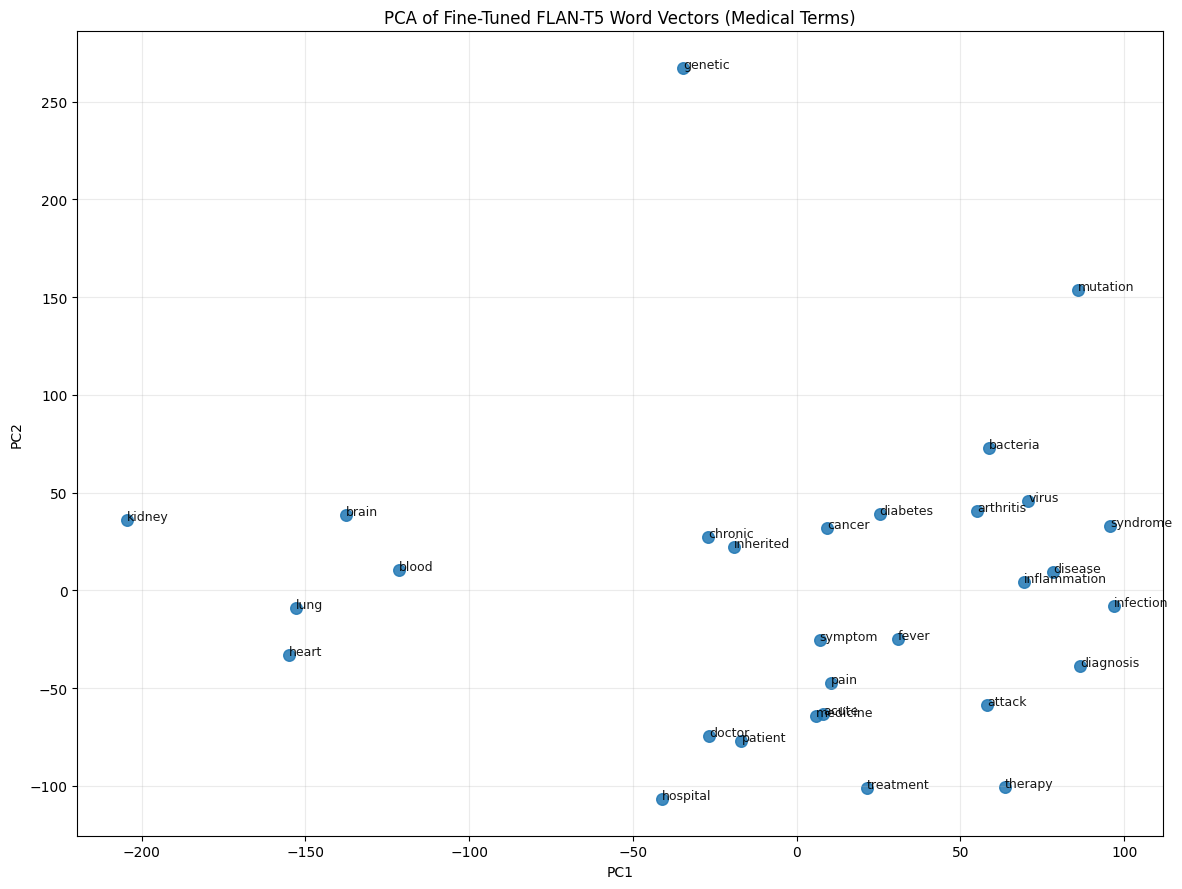

In [12]:
# Visualize word vectors from the fine-tuned model using PCA.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

candidate_words = [
    "heart", "attack", "blood", "disease", "pain", "fever", "kidney", "lung", "brain", "cancer",
    "virus", "bacteria", "infection", "treatment", "medicine", "doctor", "hospital", "patient", "symptom", "diagnosis",
    "therapy", "genetic", "inherited", "mutation", "syndrome", "chronic", "acute", "inflammation", "arthritis", "diabetes",
]

embedding_matrix = trainer.model.get_input_embeddings().weight.detach().cpu().numpy()
unk_id = tokenizer.unk_token_id

selected_words = []
selected_vectors = []

for word in candidate_words:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if not token_ids:
        continue

    # Keep words that can be represented without unknown tokens.
    if unk_id is not None and any(token_id == unk_id for token_id in token_ids):
        continue

    word_vector = embedding_matrix[token_ids].mean(axis=0)
    selected_words.append(word)
    selected_vectors.append(word_vector)

if len(selected_words) < 20:
    raise ValueError(f"Only found {len(selected_words)} known words. Add more candidate words.")

selected_vectors = np.array(selected_vectors)
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(selected_vectors)

plt.figure(figsize=(12, 9))
plt.scatter(coords[:, 0], coords[:, 1], s=70, alpha=0.85)
for idx, word in enumerate(selected_words):
    plt.annotate(word, (coords[idx, 0], coords[idx, 1]), fontsize=9, alpha=0.9)

plt.title("PCA of Fine-Tuned FLAN-T5 Word Vectors (Medical Terms)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
print(f"Words visualized: {len(selected_words)}")
print("List:", ", ".join(selected_words))
plt.show()

## Conclusion

This notebook fine-tunes a pretrained medical-domain LLM for question answering using a Hugging Face dataset from the **Medical LLMs Finetuning Datasets** collection.

Summary of the chosen setup:
- **Task:** medical question answering
- **Domain:** healthcare / medicine
- **LLM:** `google/flan-t5-small`
- **Evaluation:** ROUGE scores and exact match on generated answers

For a stronger run, increase the training subset size and train for more epochs on a GPU.